In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DATA_DIR   = '../data/'
TRAIN_FILE = DATA_DIR + 'sales.csv'
TEST_FILE  = DATA_DIR + 'sample_submission.csv'
OUT_FILE   = DATA_DIR + 'submission_baseline.csv'

In [2]:
promotions = pd.read_csv('../data/promotions.csv', parse_dates=['start_date', 'end_date'])

In [3]:
train = pd.read_csv(TRAIN_FILE, parse_dates=['Date'])
test  = pd.read_csv(TEST_FILE,  parse_dates=['Date'])

print('Train shape:', train.shape)
print('Train date range:', train['Date'].min().date(), '→', train['Date'].max().date())
print()
print('Test shape:', test.shape)
print('Test date range:', test['Date'].min().date(), '→', test['Date'].max().date())
print()
train.tail()

Train shape: (3833, 3)
Train date range: 2012-07-04 → 2022-12-31

Test shape: (548, 3)
Test date range: 2023-01-01 → 2024-07-01



,Date,Revenue,COGS
3828,2022-12-27,2100553.66,2184872.24
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15
3832,2022-12-31,2383037.48,2279288.13


In [4]:
train_index = train.Date.dt.year < 2021
test_index  = ~train_index

In [5]:
train['year']       = train['Date'].dt.year
train['day_of_year'] = train['Date'].dt.dayofyear
train['month']      = train['Date'].dt.month
train['day']        = train['Date'].dt.day


In [6]:
def generateBase(predictedYear):
    upper = predictedYear - 1
    # ── Fit on 2012–2020 only ────────────────────────────────────────────────────
    train_pre = train[train['year'] <= upper].copy()

    # Seasonal profile
    annual_means_pre = train_pre.groupby('year')[['Revenue', 'COGS']].transform('mean')
    train_pre['rev_norm']  = train_pre['Revenue'] / annual_means_pre['Revenue']
    train_pre['cogs_norm'] = train_pre['COGS']    / annual_means_pre['COGS']

    seasonal_pre = (
        train_pre
        .groupby(['month', 'day'])[['rev_norm', 'cogs_norm']]
        .mean()
        .reset_index()
    )

    # YoY growth 2013–predicted year
    annual_pre      = train_pre.groupby('year')[['Revenue', 'COGS']].sum()
    full_years_pre  = annual_pre.loc[2013:upper]
    yoy_rev_pre     = full_years_pre['Revenue'].pct_change().dropna()
    yoy_cogs_pre    = full_years_pre['COGS'].pct_change().dropna()
    growth_rev_pre  = (1 + yoy_rev_pre).prod()  ** (1 / len(yoy_rev_pre))
    growth_cogs_pre = (1 + yoy_cogs_pre).prod() ** (1 / len(yoy_cogs_pre))

    # Base level: 2020 (last year before validation window)
    base_rev_pre  = annual_pre.loc[upper, 'Revenue'] / 365
    base_cogs_pre = annual_pre.loc[upper, 'COGS']    / 365

    # ── Predict 2021–2022 (zero leakage) ─────────────────────────────────────────
    val = (train[train['year'].isin([predictedYear])]
        [['Date', 'year', 'month', 'day', 'Revenue', 'COGS']]
        .copy())

    val = val.merge(seasonal_pre, on=['month', 'day'], how='left')
    val['rev_norm']  = val['rev_norm'].fillna(1.0)
    val['cogs_norm'] = val['cogs_norm'].fillna(1.0)
    val['years_ahead'] = val['year'] - upper

    val['Revenue_pred'] = base_rev_pre  * growth_rev_pre**val['years_ahead']  * val['rev_norm']
    val['COGS_pred']    = base_cogs_pre * growth_cogs_pre**val['years_ahead'] * val['cogs_norm']

    def mape(actual, pred):
        return (np.abs(actual - pred) / actual).mean() * 100

    return dict(zip(val['Date'], val['Revenue_pred']))

In [7]:
years = np.arange(2015, 2023)

In [8]:
train['Revenue_pred'] = np.nan
revenue_pred = {}
for year in years:
    revenue_pred = revenue_pred | generateBase(year)
    # train['Revenue_pred'] = train['Date'].map(generateBase(year))
train['Revenue_pred'] = train['Date'].map(revenue_pred)
   

In [ ]:
def create_time_features(df, min_date):
    
    # Tạo bản copy để không sửa dataframe gốc
    df = df.copy()
    
    # Lấy thứ trong tuần
    df["dayofweek"] = df["Date"].dt.dayofweek
    
    
    # Lấy ngày thứ bao nhiêu trong năm
    df["dayofyear"] = df["Date"].dt.dayofyear
    
    
    # Lấy tuần thứ bao nhiêu trong năm
    df["weekofyear"] = df["Date"].dt.isocalendar().week.astype(int)
    
   
    
    # Kiểm tra ngày đó có phải ngày cuối tháng không
    df["is_month_end"] = df["Date"].dt.is_month_end.astype(int)
    
    
    # Tạo biến thời gian tính từ ngày đầu tiên trong train
    # Ngày đầu tiên = 0, ngày tiếp theo = 1,...
    # Giúp model học long-term trend
    df["time_idx"] = (df["Date"] - min_date).dt.days
    
    
    # Tạo cyclical features cho tháng
    # Tháng 12 và tháng 1 thực ra gần nhau trong chu kỳ năm
    # Nếu chỉ dùng số 12 và 1 thì model có thể hiểu nhầm là chúng rất xa nhau
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    
    
    # Tạo cyclical features cho thứ trong tuần
    # Chủ nhật và thứ hai cũng gần nhau theo chu kỳ tuần
    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
    
    
    # Tạo seasonal features theo năm
    # Các biến này giúp model học pattern lặp lại theo năm
    df["year_sin_1"] = np.sin(2 * np.pi * df["dayofyear"] / 365.25)
    df["year_cos_1"] = np.cos(2 * np.pi * df["dayofyear"] / 365.25)
    
    # Sóng thứ hai để bắt pattern phức tạp hơn một chút
    df["year_sin_2"] = np.sin(4 * np.pi * df["dayofyear"] / 365.25)
    df["year_cos_2"] = np.cos(4 * np.pi * df["dayofyear"] / 365.25)
    
    
    # Trả lại dataframe sau khi thêm feature
    return df

In [10]:
train['residual'] = train['Revenue'] - train['Revenue_pred']
train['lag_365'] = train['residual'].shift(365)
train['lag_372'] = train['residual'].shift(372)  # 365 + 7 (1 tuần)

In [13]:
all_promo_dates = []
for _, row in promotions.iterrows():
    date_range = pd.date_range(row['start_date'], row['end_date'])
    temp_df = pd.DataFrame({
        'Date': date_range,
        'has_promo': 1,
        'promo_discount': row['discount_value'],
        'promo_type_perc': 1 if row['promo_type'] == 'percentage' else 0
    })
    all_promo_dates.append(temp_df)

promo_daily = pd.concat(all_promo_dates).drop_duplicates('Date')

In [14]:
ml_data = create_time_features(train, min_date=train['Date'].min())

In [15]:
ml_data = ml_data.merge(promo_daily, on='Date', how='left')
ml_data['has_promo'] = ml_data['has_promo'].fillna(0)
ml_data['promo_discount'] = ml_data['promo_discount'].fillna(0)
ml_data['promo_type_perc'] = ml_data['promo_type_perc'].fillna(0)
ml_data.head()

,Date,Revenue,COGS,year,month,day,Revenue_pred,lag_365,lag_372,dayofweek,...,month_cos,dow_sin,dow_cos,year_sin_1,year_cos_1,year_sin_2,year_cos_2,has_promo,promo_discount,promo_type_perc
0,2016-01-08,2738103.45,2202044.96,2016,1,8,2.272713e+06,-1.515342e+06,-2.051399e+06,4,...,0.866025,-0.433884,-0.900969,0.137185,0.990545,0.271777,0.962360,0.0,0.0,0.0
1,2016-01-09,3026961.32,2446095.09,2016,1,9,2.391503e+06,-4.132435e+05,-1.538975e+06,5,...,0.866025,-0.974928,-0.222521,0.154204,0.988039,0.304719,0.952442,0.0,0.0,0.0
2,2016-01-10,4122392.05,3201417.67,2016,1,10,2.464102e+06,-1.017238e+06,-1.609194e+06,6,...,0.866025,-0.781831,0.623490,0.171177,0.985240,0.337301,0.941397,0.0,0.0,0.0
3,2016-01-11,3434076.67,2780091.13,2016,1,11,3.026530e+06,3.190552e+05,-1.320292e+05,0,...,0.866025,0.000000,1.000000,0.188099,0.982150,0.369484,0.929237,0.0,0.0,0.0
4,2016-01-12,2627637.47,2110300.27,2016,1,12,2.787856e+06,-5.946593e+05,-4.772506e+05,1,...,0.866025,0.781831,0.623490,0.204966,0.978769,0.401229,0.915978,0.0,0.0,0.0


In [16]:
y = ml_data[['Date', 'Revenue', 'Revenue_pred']]
y['residual'] = y['Revenue'] - y['Revenue_pred']
y_val = y['residual'].to_frame()
train_index = train.Date.dt.year <= 2021
test_index  = ~train_index
X = ml_data.drop(['Revenue', 'Date', 'COGS'], axis=1)

In [17]:
from lightgbm import LGBMRegressor

In [18]:
train_index = X.year <= 2021
test_index  = ~train_index

X_train, X_test = X[train_index], X[test_index]
y_train, y_test = y_val[train_index], y_val[test_index]

In [19]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data (computes mean and std) and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the statistics from training data
X_test_scaled = scaler.transform(X_test)

In [20]:
model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="rmse"
)

y_pred = model.predict(X_test, num_iteration=model.best_iteration_)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004471 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2452
[LightGBM] [Info] Number of data points in the train set: 2185, number of used features: 22
[LightGBM] [Info] Start training from score -591387.108012


In [21]:
y_test_val = y[test_index]

In [22]:
y_test_val['res_pred'] = y_pred

In [23]:
y_test_val

,Date,Revenue,Revenue_pred,residual,res_pred
2185,2022-01-01,2932155.47,2.316551e+06,6.156043e+05,-464986.927540
2186,2022-01-02,2361965.00,1.023240e+06,1.338725e+06,-6916.482548
2187,2022-01-03,545563.72,9.363837e+05,-3.908200e+05,-77497.828871
2188,2022-01-04,1242319.38,9.947657e+05,2.475537e+05,-118928.185344
2189,2022-01-05,809977.60,1.125888e+06,-3.159109e+05,-13309.608894
...,...,...,...,...,...
2545,2022-12-27,2100553.66,1.917613e+06,1.829408e+05,-355990.218204
2546,2022-12-28,3448729.20,3.249039e+06,1.996904e+05,-430919.003355
2547,2022-12-29,3083944.33,3.577249e+06,-4.933045e+05,149889.391554
2548,2022-12-30,2884668.76,3.085185e+06,-2.005160e+05,246952.823602


In [34]:
y_test_val['rev_pred_2'] = y_test_val['Revenue_pred'] + y_test_val['res_pred']

In [35]:
from sklearn.metrics import mean_absolute_percentage_error

In [26]:
def mape(actual, pred):
    return (np.abs(actual - pred) / actual).mean() * 100

In [42]:
mean_absolute_percentage_error(y_test_val['Revenue'], y_test_val['Revenue_pred'])

0.21264126378409481

In [41]:
mean_absolute_percentage_error(y_test_val['Revenue'], y_test_val['rev_pred_2'])

0.2075121257455639

In [28]:
y_test_val

,Date,Revenue,Revenue_pred,residual,res_pred,rev_pred_2
2185,2022-01-01,2932155.47,2.316551e+06,6.156043e+05,-464986.927540,2.781538e+06
2186,2022-01-02,2361965.00,1.023240e+06,1.338725e+06,-6916.482548,1.030157e+06
2187,2022-01-03,545563.72,9.363837e+05,-3.908200e+05,-77497.828871,1.013882e+06
2188,2022-01-04,1242319.38,9.947657e+05,2.475537e+05,-118928.185344,1.113694e+06
2189,2022-01-05,809977.60,1.125888e+06,-3.159109e+05,-13309.608894,1.139198e+06
...,...,...,...,...,...,...
2545,2022-12-27,2100553.66,1.917613e+06,1.829408e+05,-355990.218204,2.273603e+06
2546,2022-12-28,3448729.20,3.249039e+06,1.996904e+05,-430919.003355,3.679958e+06
2547,2022-12-29,3083944.33,3.577249e+06,-4.933045e+05,149889.391554,3.427359e+06
2548,2022-12-30,2884668.76,3.085185e+06,-2.005160e+05,246952.823602,2.838232e+06


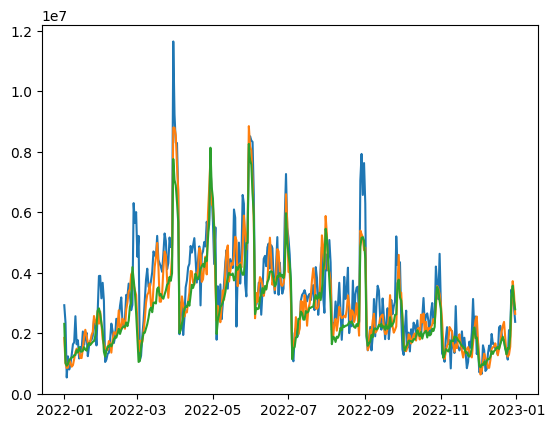

In [39]:
plt.plot(y_test_val['Date'],y_test_val['Revenue'])
plt.plot(y_test_val['Date'],y_test_val['rev_pred_2'])
plt.plot(y_test_val['Date'],y_test_val['Revenue_pred'])

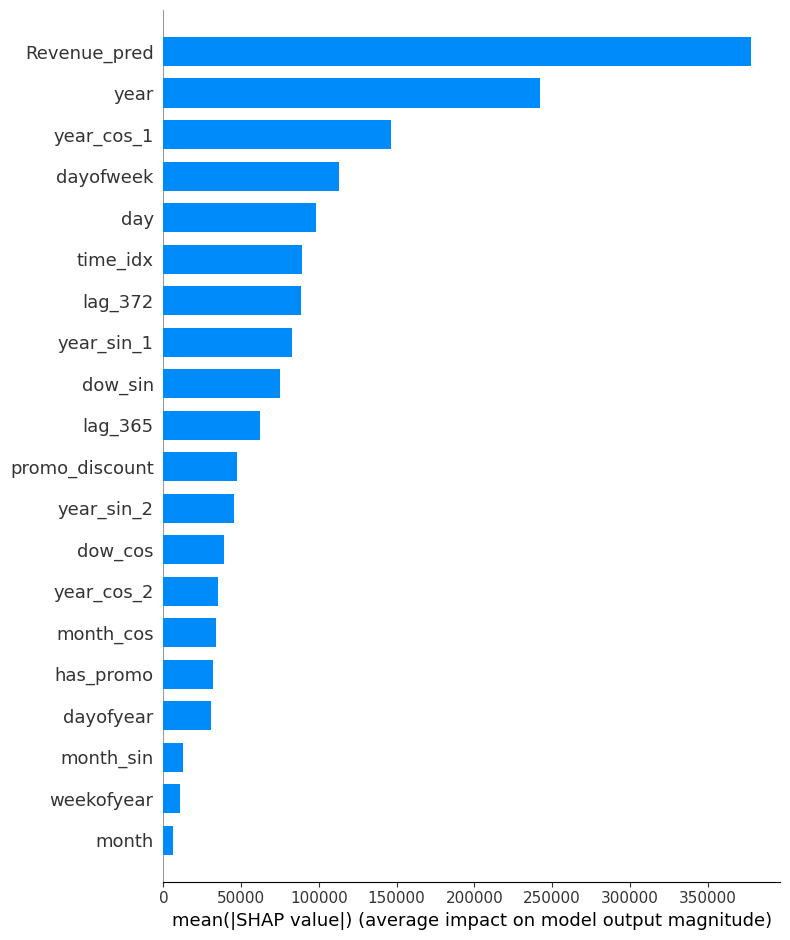

In [38]:
import shap
import shap

# 1. Create an explainer for your model
explainer = shap.Explainer(model)

# 2. Calculate SHAP values for your dataset (X)
# This returns an Explanation object (v0.36+) or a numpy array (older versions)
shap_values = explainer(X_test) 

shap.summary_plot(shap_values, X, plot_type="bar")


In [31]:
raw_values=shap_values.values

In [32]:
shap_df = pd.DataFrame(abs(raw_values), columns=X_test.columns)

In [33]:
shap_df.mean().sort_values(ascending=False)

Revenue_pred       377660.802268
year               242406.793684
year_cos_1         146363.685098
dayofweek          112777.830194
day                 98013.331245
time_idx            89230.731671
lag_372             88220.563183
year_sin_1          82806.192586
dow_sin             74947.386624
lag_365             62153.577462
promo_discount      46992.739641
year_sin_2          45136.140630
dow_cos             38758.156539
year_cos_2          34763.060207
month_cos           33694.005594
has_promo           31558.815473
dayofyear           30451.753528
month_sin           12729.599615
weekofyear          10723.910833
month                5809.544798
is_month_end         3367.104614
promo_type_perc      2306.675619
dtype: float64